Fetching data for ['TSLA', 'BND', 'SPY'] from 2015-01-01 to 2026-06-30...


[*********************100%***********************]  3 of 3 completed



Missing values per asset:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

Data successfully saved to data/processed/

Descriptive Statistics of Daily Returns:
Ticker          BND          SPY         TSLA
count   2887.000000  2887.000000  2887.000000
mean       0.000079     0.000573     0.001803
std        0.003347     0.011121     0.036018
min       -0.054385    -0.109424    -0.210628
25%       -0.001511    -0.003700    -0.016643
50%        0.000134     0.000655     0.001216
75%        0.001773     0.005930     0.019456
max        0.042201     0.105020     0.226900


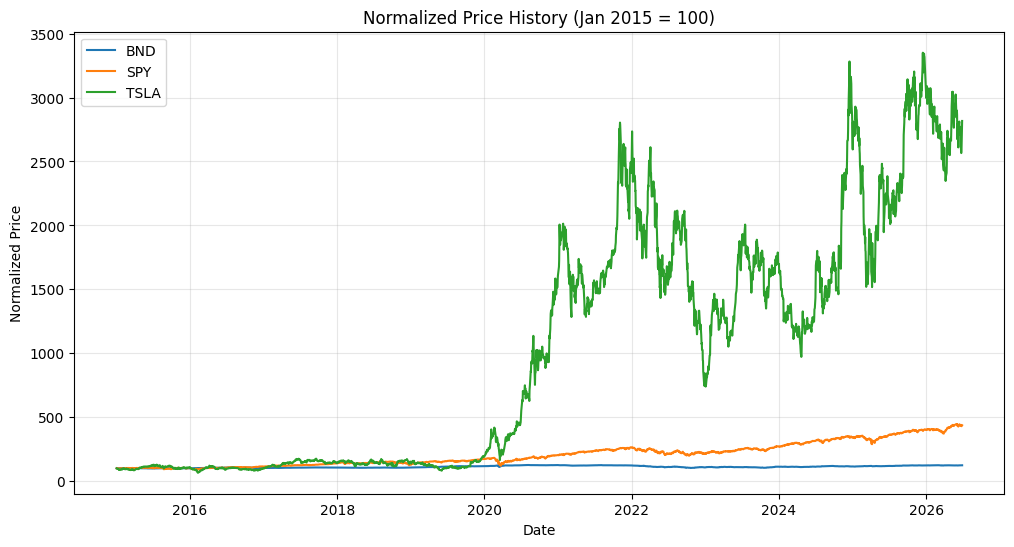

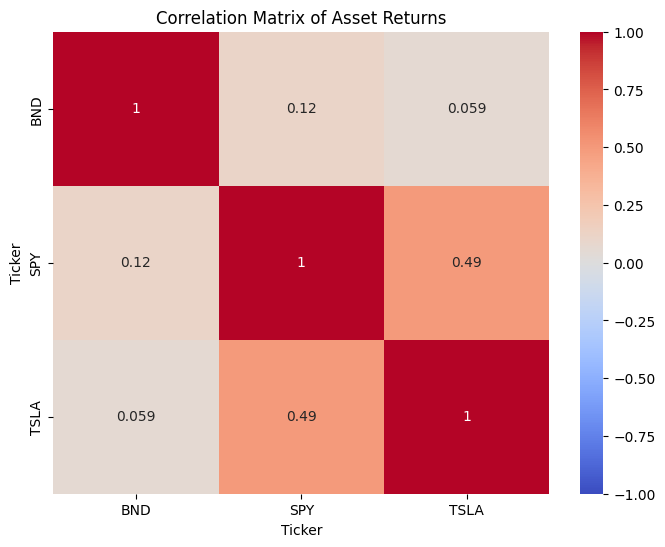

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Define parameters
tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-06-30"

# 2. Extract Historical Financial Data
print(f"Fetching data for {tickers} from {start_date} to {end_date}...")
raw_data = yf.download(tickers, start=start_date, end=end_date)

# Extract only the 'Adj Close' prices for modeling, as they account for dividends and stock splits
# If 'Adj Close' is unavailable (sometimes happens with yfinance updates), fallback to 'Close'
if 'Adj Close' in raw_data.columns:
    df_prices = raw_data['Adj Close']
else:
    df_prices = raw_data['Close']

# Extract trading volume for exploratory analysis
df_volume = raw_data['Volume']

# 3. Data Cleaning & Preprocessing
# Check for missing values
missing_values = df_prices.isnull().sum()
print("\nMissing values per asset:")
print(missing_values)

# Forward fill missing values (common practice for financial time series, assuming price stays the same on non-trading days)
df_prices = df_prices.ffill().bfill() 

# Calculate daily returns (percentage change), which is critical for portfolio optimization
df_returns = df_prices.pct_change().dropna()

# 4. Save the organized data to your 'data/processed' directory
os.makedirs('../data/processed', exist_ok=True) # Ensure directory exists relative to notebooks folder
df_prices.to_csv('../data/processed/asset_prices.csv')
df_returns.to_csv('../data/processed/asset_returns.csv')
print("\nData successfully saved to data/processed/")

# 5. Exploratory Data Analysis (EDA)
# Display basic statistical properties
print("\nDescriptive Statistics of Daily Returns:")
print(df_returns.describe())

# Plotting Normalized Prices to compare trends
plt.figure(figsize=(12, 6))
normalized_prices = df_prices / df_prices.iloc[0] * 100
for c in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[c], label=c)
    
plt.title('Normalized Price History (Jan 2015 = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plotting the Correlation Matrix (Important for diversification)
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Asset Returns')
plt.show()